In [53]:
import numpy as np
import pandas as pd
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


### Lectura de datos usando escalado (-1,1)

In [ ]:
#Ejecutar para carcar datos y escalarlos:

df = pd.read_csv('csv/radiomicas_combinadas_normalizado.csv')
df["Patient"] = df["Patient"].str.replace('"','',regex=False)
df.head(5)

### Lectura de datos usando estadarizado al z-value

In [20]:
#Ejecutar para cargar dtos y estandarizárlos:

df = pd.read_csv('csv/radiomicas_combinadas.csv')
df["Patient"] = df["Patient"].str.replace('"','',regex=False)

df_scaled = df.copy()
df_scaled.iloc[:, 1:] = StandardScaler().fit_transform(df_scaled.iloc[:, 1:])
df = df_scaled
df.head(5)

,Patient,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_Mean,original_firstorder_MeanAbsoluteDeviation,...,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume
0,LUNG1-001,-0.770901,-0.535339,2.935450,0.491218,-0.139063,-0.912903,1.967610,-0.462555,0.662133,...,-1.410213,-1.653561,3.202783,-1.622792,3.145457,1.454056,1.727631,1.885736,-2.628924,3.143044
1,LUNG1-002,0.747366,0.936893,-0.456281,-0.794639,-0.390801,1.400323,-0.617684,0.976466,-0.806721,...,1.212883,0.959914,-0.251793,1.072434,0.346733,2.059645,-0.577140,1.050606,-0.267202,0.348722
2,LUNG1-003,0.663018,1.163391,-0.416535,-0.218115,-0.269594,0.522257,1.604981,0.903976,-0.658090,...,0.421209,0.263416,-0.155420,0.242282,0.210093,1.865169,-0.361680,0.622879,-0.376805,0.206598
3,LUNG1-004,0.077266,0.181902,-0.006347,0.399409,-0.232299,-0.549426,-0.239424,-0.000251,0.196286,...,-0.443854,0.263661,-0.360082,0.157081,-0.190146,-0.765180,-0.309853,-0.089733,0.048680,-0.187867
4,LUNG1-005,-1.811196,0.332901,1.789323,1.170775,0.233883,-1.067267,-0.561414,-0.913973,1.507316,...,0.168824,0.422162,0.227011,0.311448,0.346201,0.616647,-0.103549,0.612935,-0.749060,0.346424


### Lectura de datos de clasificaciones de pacientes

In [21]:
df2 = pd.read_csv('csv/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv')
df2.head(5)

,PatientID,age,clinical.T.Stage,Clinical.N.Stage,Clinical.M.Stage,Overall.Stage,Histology,gender,Survival.time,deadstatus.event
0,LUNG1-001,78.7515,2.0,3,0,IIIb,large cell,male,2165,1
1,LUNG1-002,83.8001,2.0,0,0,I,squamous cell carcinoma,male,155,1
2,LUNG1-003,68.1807,2.0,3,0,IIIb,large cell,male,256,1
3,LUNG1-004,70.8802,2.0,1,0,II,squamous cell carcinoma,male,141,1
4,LUNG1-005,80.4819,4.0,2,0,IIIb,squamous cell carcinoma,male,353,1


In [24]:
df2 = df2[df2["PatientID"].isin(df["Patient"])]  # Keep only patients in df
print(df.shape)
print(df2.shape)


(418, 108)
(418, 10)


### Selección de características 

In [29]:
SELECTOR = "stable" #all, stable, firstorder, glcm, gldm, glrlm, glszm, ngtdm, shape

stable_features = ['original_shape_SurfaceVolumeRatio', 'original_shape_LeastAxisLength', 
                   'original_gldm_GrayLevelNonUniformity', 'original_glrlm_GrayLevelNonUniformity', 
                   'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_glrlm_RunLengthNonUniformity', 
                   'original_glszm_ZoneVariance', 'original_glszm_LargeAreaEmphasis', 
                   'original_shape_MinorAxisLength', 'original_gldm_DependenceNonUniformity', 
                   'original_glszm_GrayLevelNonUniformity', 'original_shape_Maximum2DDiameterRow',
                     'original_glszm_SizeZoneNonUniformity', 'original_shape_MeshVolume', 'original_shape_VoxelVolume']

switcher = {
    "all": (df.columns[1:], "Seleccionadas todas las caractrísticas."),
    "stable": (stable_features, "Seleccionadas características estables."),
    "firstorder": (df.filter(like='original_firstorder').columns, "Seleccionadas características de primer orden."),
    "glcm": (df.filter(like='original_glcm').columns, "Seleccionadas características de GLCM."),
    "gldm": (df.filter(like='original_gldm').columns, "Seleccionadas características de GLDM."),
    "glrlm": (df.filter(like='original_glrlm').columns, "Seleccionadas características de GLRLM."),
    "glszm": (df.filter(like='original_glszm').columns, "Seleccionadas características de GLSZM."),
    "ngtdm": (df.filter(like='original_ngtdm').columns, "Seleccionadas características de NGTDM."),
    "shape": (df.filter(like='original_shape').columns, "Seleccionadas características de forma.")
}



#Ejecutar para seleccionar todas las características:
features = switcher.get(SELECTOR, (df.columns[1:], "Seleccionadas todas las caractrísticas."))[0]
print(switcher.get(SELECTOR, (df.columns[1:], "Seleccionadas todas las caractrísticas."))[1])

Seleccionadas características estables.


### Árboles de decisión

#### Por Overall Stage

In [69]:
classifier = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=0)
df_clean = df[features].join(df2["Overall.Stage"]).dropna()
print(df_clean["Overall.Stage"].value_counts(normalize=True))
scores = cross_val_score(classifier, df_clean[features], df_clean["Overall.Stage"], cv=5)
classifier.fit(df_clean[features], df_clean["Overall.Stage"])
print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Overall.Stage
IIIb    0.421308
IIIa    0.263923
I       0.220339
II      0.094431
Name: proportion, dtype: float64
Cross-validation scores: [0.30120482 0.39759036 0.38554217 0.36585366 0.41463415]
Average CV score: 0.37296503085512783


Misses: 219
Depth: 3
Number of leaves: 8


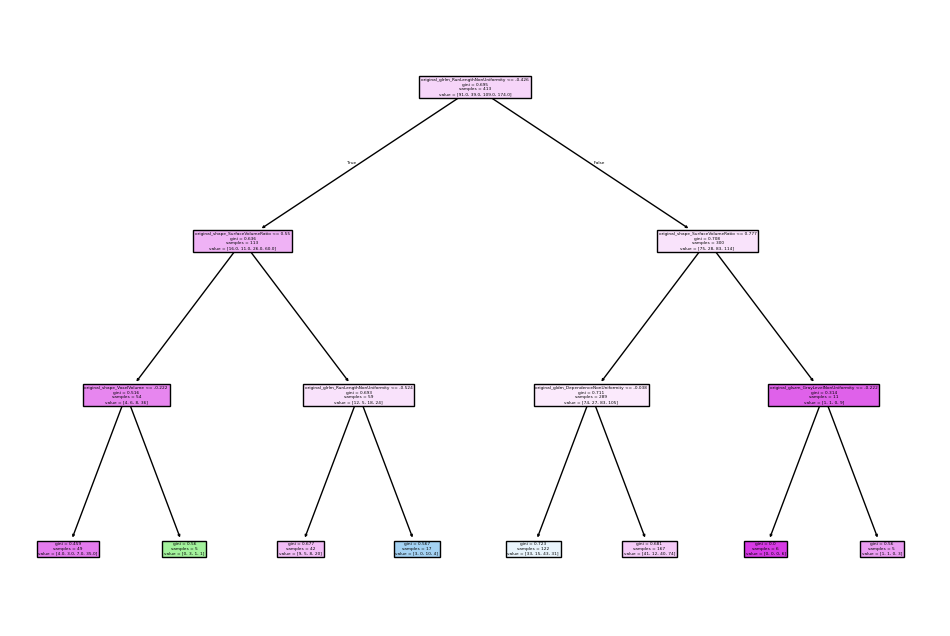

In [66]:
predictions = classifier.predict(df_clean[features]) 
print("Misses:", np.sum(predictions != df_clean["Overall.Stage"]))
print("Depth:", classifier.get_depth())
print("Number of leaves:",classifier.get_n_leaves())


plt.figure(figsize=(12,8))
plot_tree(classifier, feature_names=features, filled=True)
plt.show()

#### Por T Stage

In [ ]:

classifier = DecisionTreeClassifier(max_depth=3, random_state=0)
df_clean = df[features].join(df2["clinical.T.Stage"]).dropna()
print(df_clean["clinical.T.Stage"].value_counts(normalize=True))
scores = cross_val_score(classifier, df_clean[features], df_clean["clinical.T.Stage"], cv=5)
classifier.fit(df_clean[features], df_clean["clinical.T.Stage"])
print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

clinical.T.Stage
2.0    0.368039
4.0    0.280872
1.0    0.222760
3.0    0.123487
5.0    0.004843
Name: proportion, dtype: float64
Cross-validation scores: [0.3253012  0.36144578 0.36144578 0.30487805 0.35365854]
Average CV score: 0.3413458712900382


/home/roth/aaron/TFG/code/venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Misses: 232
Depth: 3
Number of leaves: 7


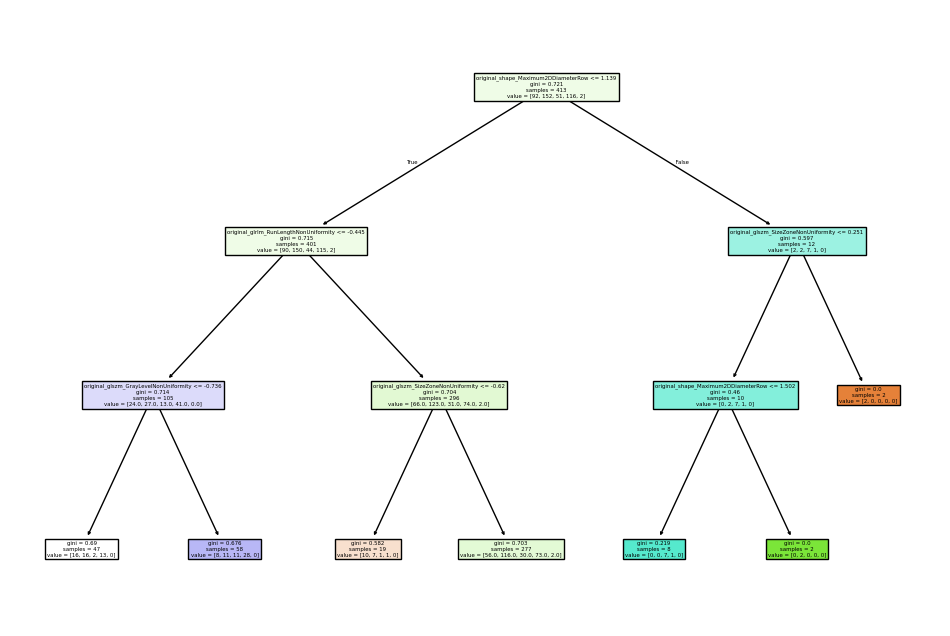

In [74]:
predictions = classifier.predict(df_clean[features]) 
print("Misses:", np.sum(predictions != df_clean["clinical.T.Stage"]))
print("Depth:", classifier.get_depth())
print("Number of leaves:",classifier.get_n_leaves())


plt.figure(figsize=(12,8))
plot_tree(classifier, feature_names=features, filled=True)
plt.show()